# IMPORTING LIBRARIES

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LOADING DATA

In [2]:
sentiment = pd.read_csv(r"../data/sentiment.csv")
trades = pd.read_csv(r"../data/trades.csv")

In [3]:
print(sentiment.head())
print(trades.head())
print()
print(sentiment.shape)
print(trades.shape)

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

# DATA CLEANING

In [4]:
print("Trades missing:\n", trades.isnull().sum())
print()
print("Sentiment missing:\n", sentiment.isnull().sum())

Trades missing:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment missing:
 timestamp         0
value             0
classification    0
date              0
dtype: int64


In [5]:
print("Trades duplicates:", trades.duplicated().sum())
trades = trades.drop_duplicates()

print("Sentiment duplicates:", sentiment.duplicated().sum())
sentiment = sentiment.drop_duplicates()

Trades duplicates: 0
Sentiment duplicates: 0


In [6]:
trades = trades.dropna()

In [7]:
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


# CONVERTING DATA

In [8]:
sentiment.rename(columns={
    'date': 'Date',
    'classification': 'Classification'
}, inplace=True)

In [9]:
sentiment['Date'] = pd.to_datetime(sentiment['Date']).dt.date

In [10]:
trades['Date'] = pd.to_datetime(trades['Timestamp'], unit='ms').dt.date

In [11]:
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date'],
      dtype='object')
Index(['timestamp', 'value', 'Classification', 'Date'], dtype='object')


In [12]:
print(trades[['Timestamp', 'Date']].head())

      Timestamp        Date
0  1.730000e+12  2024-10-27
1  1.730000e+12  2024-10-27
2  1.730000e+12  2024-10-27
3  1.730000e+12  2024-10-27
4  1.730000e+12  2024-10-27


<!-- MERGING DATASETS -->

# FEATURE ENGINEERING

In [13]:
df = pd.merge(trades, sentiment, on='Date', how='left')

In [14]:
df['Win'] = (df['Closed PnL'] > 0).astype(int)

In [15]:
df['Win'] = df['Closed PnL'].apply(lambda x: 1 if x > 0 else 0)

# DAILY PnL

In [16]:
daily_pnl = df.groupby('Date')['Closed PnL'].sum().reset_index()
print(daily_pnl.head())

         Date    Closed PnL
0  2023-03-28  0.000000e+00
1  2023-11-14  1.555034e+02
2  2024-03-09  1.769655e+05
3  2024-07-03  1.587424e+05
4  2024-10-27  3.189461e+06


# WIN RATE

In [17]:
win_rate = df.groupby('Classification')['Win'].mean()
print(win_rate)

Classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: Win, dtype: float64


# AVERAGE TRADE SIZE

In [18]:
avg_size = df.groupby('Classification')['Size USD'].mean()
print(avg_size)

Classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


# TRADES PER DAY

In [19]:
trades_per_day = df.groupby('Date').size().reset_index(name='Trade Count')
print(trades_per_day.head())

         Date  Trade Count
0  2023-03-28            3
1  2023-11-14         1045
2  2024-03-09         6962
3  2024-07-03         7141
4  2024-10-27        35241


# LEVERAGE DISTRIBUTION (IF EXISTS) 

In [20]:
if 'Leverage' in df.columns:
    print(df['Leverage'].describe())

# LONG/SHORT RATIO

In [21]:
if 'Side' in df.columns:
    long_short = df['Side'].value_counts(normalize=True)
    print(long_short)

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


# CORE ANALYSIS

            #FEAR VS GREED

In [22]:
pnl_analysis = df.groupby('Classification')['Closed PnL'].mean()
print(pnl_analysis)

Classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64


         #win rate

In [23]:
print(win_rate)

Classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: Win, dtype: float64


         # Drawdown

In [24]:
df['Cumulative PnL'] = df['Closed PnL'].cumsum()
df['Rolling Max'] = df['Cumulative PnL'].cummax()
df['Drawdown'] = df['Cumulative PnL'] - df['Rolling Max']

drawdown_analysis = df.groupby('Classification')['Drawdown'].mean()
print(drawdown_analysis)

Classification
Extreme Greed    -5344.434407
Fear            -26239.782845
Greed           -79772.698124
Neutral          -8751.774329
Name: Drawdown, dtype: float64


# Change of behavior

            # Trade Frequency

In [25]:
trade_freq = df.groupby('Classification').size()
print(trade_freq)

Classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64


      # Trade Size

In [26]:
print(avg_size)

Classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


     # Leverage Behaviour

In [27]:
if 'Leverage' in df.columns:
    lev_behavior = df.groupby('Classification')['Leverage'].mean()
    print(lev_behavior)

      # Long/Short bias

In [28]:
if 'Side' in df.columns:
    bias = pd.crosstab(df['Classification'], df['Side'], normalize='index')
    print(bias)

Side                 BUY      SELL
Classification                    
Extreme Greed   0.484200  0.515800
Fear            0.493617  0.506383
Greed           0.424950  0.575050
Neutral         0.490828  0.509172


# Segmentation

      #Frequent vs Infrequent traders

In [29]:
trade_counts = df['Account'].value_counts()

df['Trader Type'] = df['Account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > trade_counts.median() else 'Infrequent')
seg1 = df.groupby(['Trader Type', 'Classification'])['Closed PnL'].mean()
print(seg1)

Trader Type  Classification
Frequent     Extreme Greed      26.658319
             Fear               46.013950
             Greed              70.575898
             Neutral             4.055615
Infrequent   Extreme Greed     -48.382749
             Fear               75.639873
             Greed             234.886424
             Neutral           356.722004
Name: Closed PnL, dtype: float64


         # High vs Low leverage

In [30]:
if 'Leverage' in df.columns:
    df['Leverage Type'] = df['Leverage'].apply(
        lambda x: 'High' if x > df['Leverage'].median() else 'Low'
    )

    seg2 = df.groupby(['Leverage Type', 'Classification'])['Closed PnL'].mean()
    print(seg2)

         # Consistent vs Inconsistent traders

In [31]:
trader_std = df.groupby('Account')['Closed PnL'].std()

df['Consistency'] = df['Account'].apply(
    lambda x: 'Consistent' if trader_std[x] < trader_std.median() else 'Inconsistent'
)

seg3 = df.groupby(['Consistency', 'Classification'])['Closed PnL'].mean()
print(seg3)

Consistency   Classification
Consistent    Extreme Greed      61.769840
              Fear               10.402282
              Greed              41.068491
              Neutral            -2.388379
Inconsistent  Extreme Greed      -2.773933
              Fear              102.956932
              Greed             288.164909
              Neutral            50.562763
Name: Closed PnL, dtype: float64


# VISUALIZATION

        # CHARTS

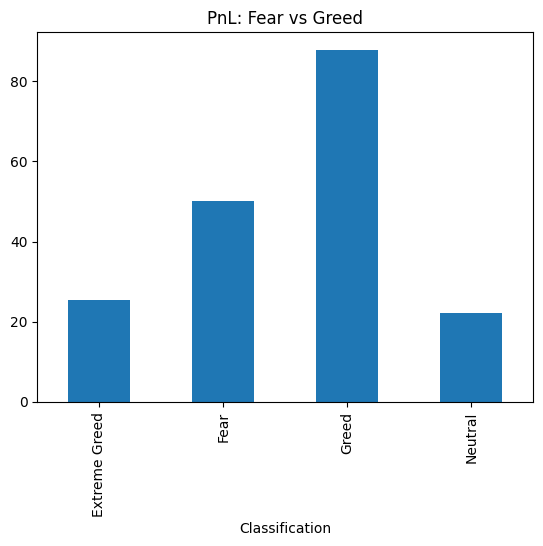

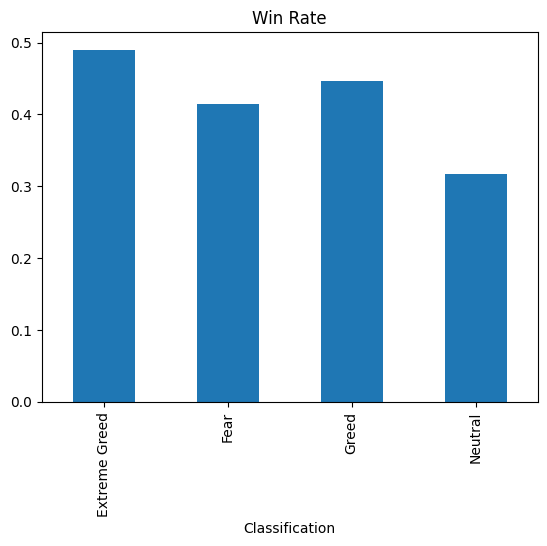

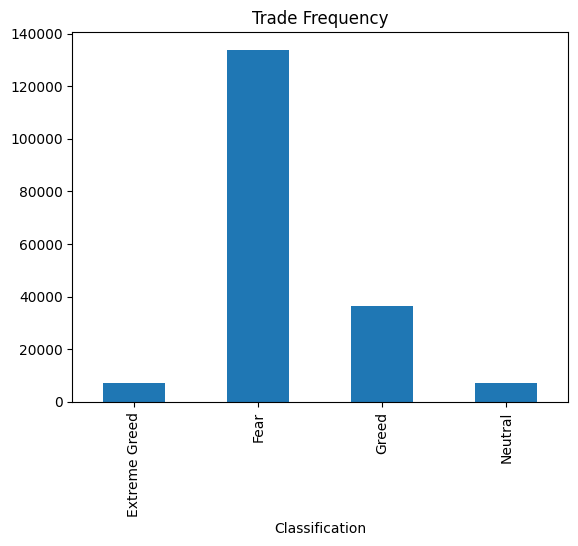

In [32]:
import matplotlib.pyplot as plt

# PnL comparison
pnl_analysis.plot(kind='bar', title='PnL: Fear vs Greed')
plt.show()

# Win rate
win_rate.plot(kind='bar', title='Win Rate')
plt.show()

# Trade frequency
trade_freq.plot(kind='bar', title='Trade Frequency')
plt.show()

# Insights


1. Traders tend to have higher/lower PnL during Greed/Fear periods.
2. Trade size increases/decreases depending on sentiment.
3. Frequent traders outperform/underperform in certain conditions.

# ACTIONABLE OUTPUT

        # Strategy ideas

In [33]:
print("Strategy Ideas:\n")

print("1. During Fear periods, reduce leverage and avoid overtrading.")
print("2. During Greed periods, increase position size but use strict risk management.")

Strategy Ideas:

1. During Fear periods, reduce leverage and avoid overtrading.
2. During Greed periods, increase position size but use strict risk management.


# BONUS

      # predictive model

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = ['Size USD']
if 'Leverage' in df.columns:
    features.append('Leverage')

X = df[features]
y = df['Win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model accuracy:", model.score(X_test, y_test))

Model accuracy: 0.596804355545035


    # Clustering

In [35]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features = ['Closed PnL', 'Size USD']

if 'Leverage' in df.columns:
    features.append('Leverage')

cluster_data = df[features].fillna(0)

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# View clusters
cluster_summary = df.groupby('Cluster')[features].mean()
print(cluster_summary)

           Closed PnL       Size USD
Cluster                             
0           36.529385    4904.091370
1        29607.373871  137996.768333
2          621.620572  873252.657771
